In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28,28,1))
x_test = np.reshape(x_test, (len(x_test), 28,28,1))

print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

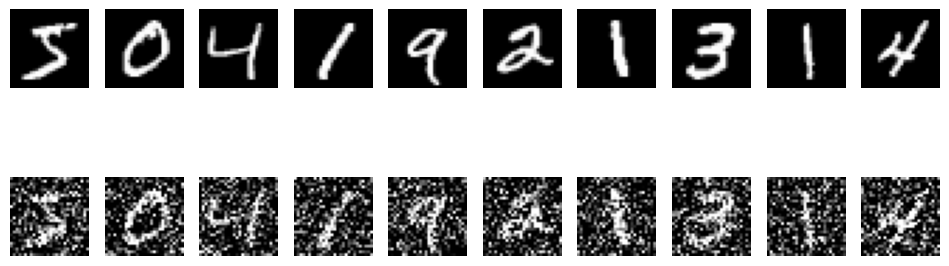

In [ ]:
plt.figure(figsize=(12,4))

for i in range(10):
    ax = plt.subplot(2,10,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.axis("off")

    ax = plt.subplot(2,10,i+11)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.show()

In [ ]:
input_img = Input(shape=(28,28,1))

# Encoder

x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x = MaxPooling2D((2,2),padding='same')(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
encoded = MaxPooling2D((2,2),padding='same')(x)

# Decoder

x = Conv2D(32,(3,3),activation='relu',padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)

autoencoder = Model(input_img, decoded)

In [ ]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 149s 312ms/step - loss: 0.1728 - val_loss: 0.1167
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 146s 312ms/step - loss: 0.1138 - val_loss: 0.1099
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 293ms/step - loss: 0.1086 - val_loss: 0.1059
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 305ms/step - loss: 0.1057 - val_loss: 0.1043
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 313ms/step - loss: 0.1035 - val_loss: 0.1017
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 285ms/step - loss: 0.1019 - val_loss: 0.1003
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 300ms/step - loss: 0.1006 - val_loss: 0.0992
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 295ms/step - loss: 0.0997 - val_loss: 0.0987
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 292ms/step - loss: 0.0990 - val_loss: 0.0981
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 291ms/step - loss: 0.0984 - val_loss: 0.0975


In [ ]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


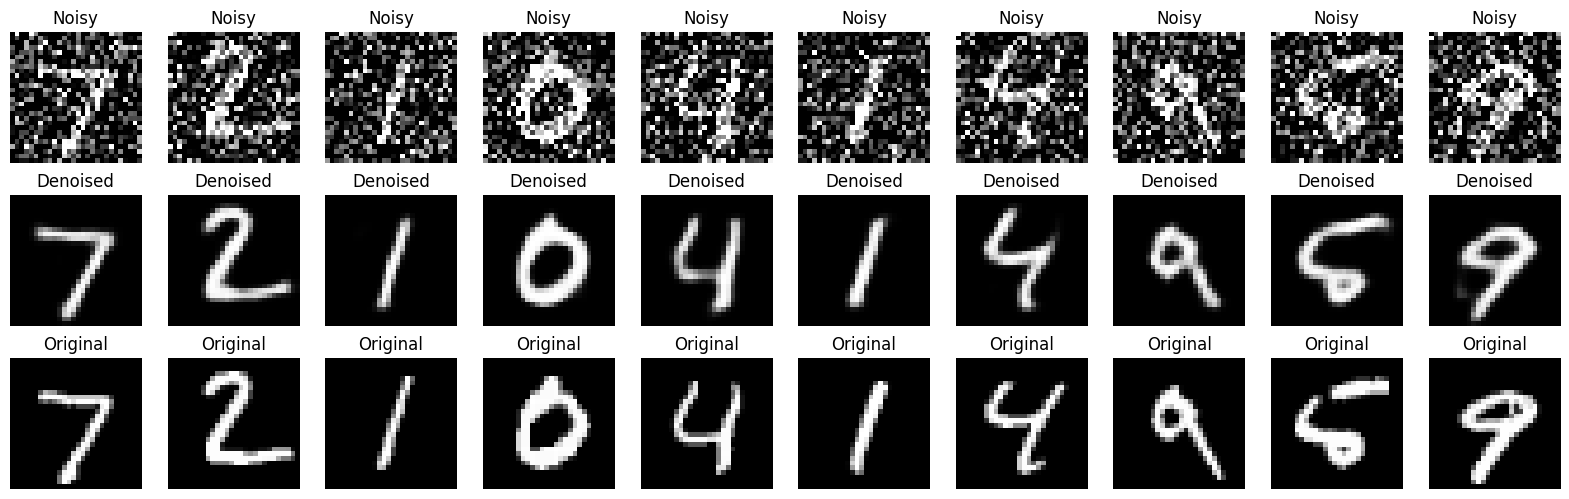

In [ ]:
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Noisy image
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised image
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

    # Original image
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

plt.show()

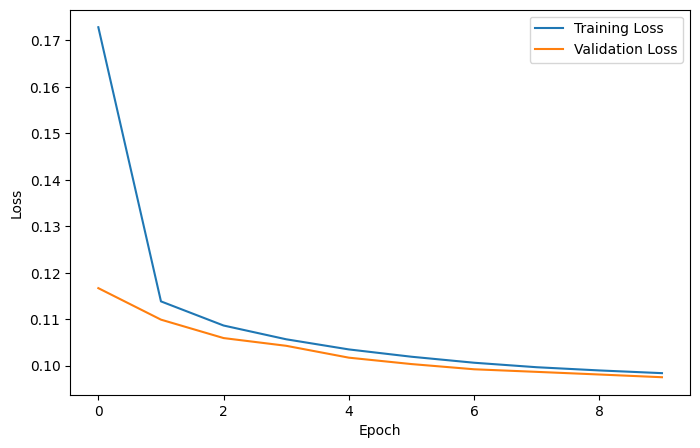

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
autoencoder.save("mnist_denoising_autoencoder.h5")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("mnist_denoising_autoencoder.h5")